# PersonaCore — Milestone 2 Evidence: Memory in the Weights

PersonaCore is a conversational AI whose **memory and personalization live in the model
weights — no databases, no vector stores, no external files.** Milestone 1 built the
from-scratch foundation. **Milestone 2 is the mechanism itself:** a LoRA adapter that teaches
the model a persona by changing its parameters, and EWC that keeps the base task intact while
that happens.

**What this notebook shows (and what it does not claim).** This is the **Milestone 2** evidence
artifact: the no-forgetting A/B, the teach-then-recall gate, the tokenizer-inflation tax carried
forward from Phase 11, and the two signature figures. It claims nothing about free-running story
quality, about recall beyond the proper-noun core, or about reversed phrasings — each of those
bounds is quoted at the end, from its own source, rather than left for a reader to discover.

**Independence from `demo.ipynb` (D-13).** This notebook is **self-contained**. It runs
top-to-bottom from a fresh clone using only files committed under `results/`, and it requires
**nothing** from `demo.ipynb` — no shared cell state, no variable, no checkpoint that notebook
loads. The reverse holds too: `demo.ipynb` is the **Milestone 1** evidence notebook, it runs
standalone, and it requires nothing from this file. Neither notebook shares cell state with the
other; run either one alone, in either order.

**Reproducibility.** Nothing here trains, samples, or opens a checkpoint. Every input is tracked
in git: `results/phase13_ab_report.md`, `results/phase14_recall_report.md`,
`results/inflation_report.md`, `results/phase15_norms.json`, and three committed PNGs.

## Headline evaluation (re-cited, never recomputed)

Every number below is committed in `results/` and re-cited here **with its denominator**. This
notebook never recomputes a headline number — the rigor lives in the audited script that produced
it, not in an ad-hoc notebook cell. Where a number carries a qualification, the qualification sits
in the same paragraph as the number, never behind a "see Limitations" pointer.

| Claim | Number | Committed in |
| --- | --- | --- |
| Retention cost of naive fine-tuning | 8.52417066884246 PPL | `results/phase13_ab_report.md` |
| Held-out closed-book recall vs its gate | 0.3483 vs 0.2000 | `results/phase14_recall_report.md` |
| Dialogue tokenizer-inflation tax | 3.229 tokens/word | `results/inflation_report.md` |

## 1. No forgetting: two arms, one bit apart, 4,000 steps

Both arms were fine-tuned fresh from the same 50k-step base `W₀` (`best.pt`) on the same dialogue
data with the same seed, config and data order, differing in exactly one bit — `penalty_fn`:
λ = 0 (naive) vs λ = 0.01 (EWC). Re-cited from `results/phase13_ab_report.md`, `## 2×2 Result`
and `## Gate Verdict`.

| Arm | λ | Acquisition — masked dialogue val PPL | Retention — retention PPL (frozen sub-bin) |
| --- | --- | --- | --- |
| _step-0 reference (shared anchor)_ | — | _31.903875386436905_ | _2.107553076833866_ |
| naive | 0 | **4.192794562524908** | **8.52417066884246** |
| EWC | 0.01 | **4.573349242745997** | **3.8911400839446597** |

Read as movement from that shared anchor: naive drifts **+6.416618** retention PPL while EWC
drifts **+1.783587** — a factor of 3.6 — and the two arms land within **0.380556** PPL of each
other on the task they were both taught. So EWC's retention win is not bought by failing to
learn. The pre-registered retention gate (`naive_ret − ewc_ret > MARGIN = 0.137860`) holds at
**33.61×** the margin.

**The qualification, in the same breath.** The gate measures **teacher-forced** retention
perplexity on a frozen sub-bin — not free-running story generation, on which the same report
records a measured negative result. And the **noise floor** the margin is built from
(Δ_ret = 0.068930) was measured on the masked arm at a 1250-step budget and was never re-verified
at the 4,000-step production budget. Both bounds are quoted verbatim at the end of this notebook.

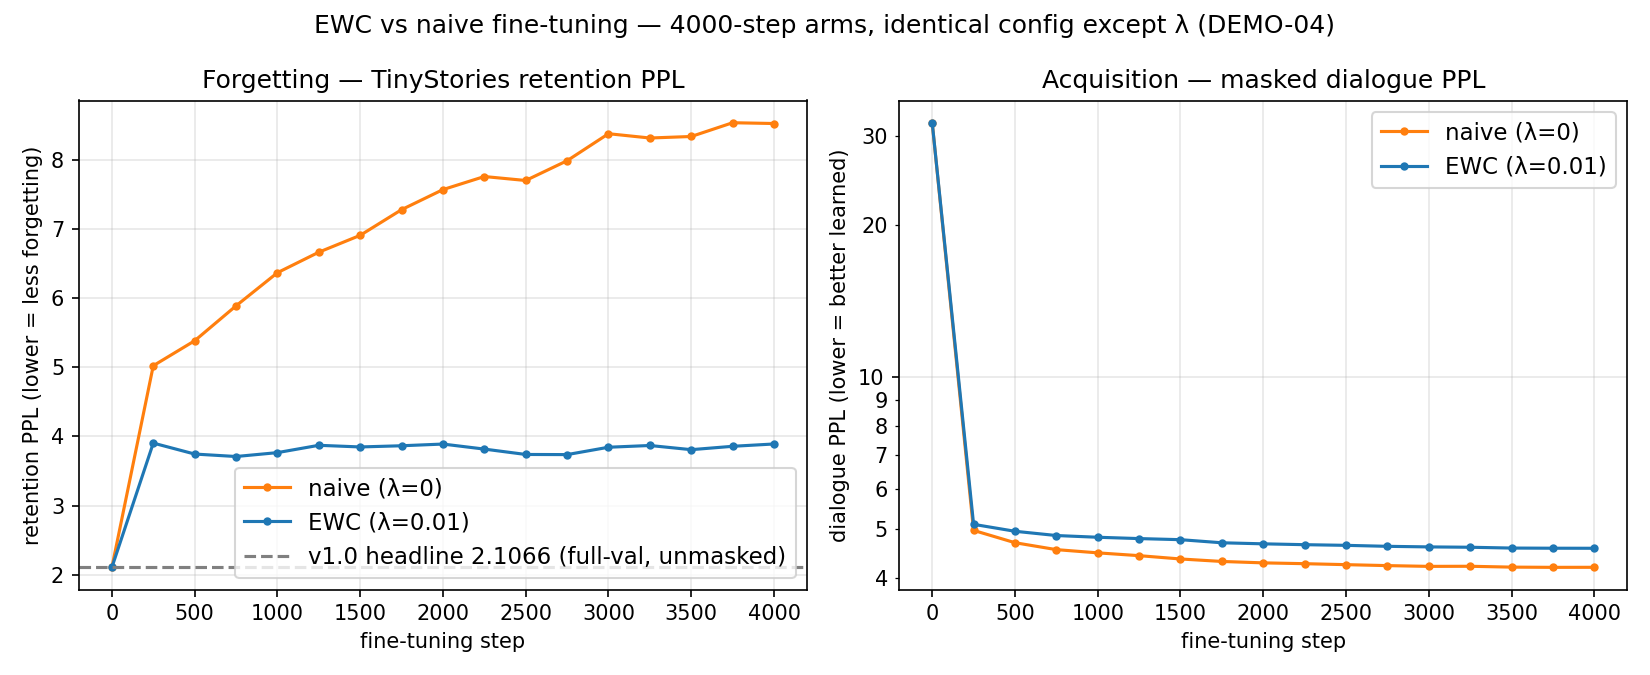

In [1]:
from IPython.display import Image, display

# Committed figure (VIZ-01, Phase 13), re-displayed rather than re-plotted. Nothing in this
# notebook opens a checkpoint or a training log — every input is a file tracked in git.
display(Image(filename="results/phase13_forgetting_curve.png"))

## 2. Teach, then recall: does the persona survive in the weights?

A LoRA adapter was taught a synthetic persona for 200 steps, then scored **closed-book** — the
fact never appears in any scored prompt, checked at both the decoded-string and the token-id
level before the model was called. Re-cited from `results/phase14_recall_report.md`,
`## Recall Results — Core Tier` and `## Verdict`.

| tier | k/N | rate | threshold | gate |
| --- | --- | --- | --- | --- |
| core taught | 496/1008 | **0.4921** | `0.2486` | **PASS** |
| core held-out | 326/936 | **0.3483** | `0.2000` | **PASS** |
| closed-book control (adapter off) | 0/2430 | **0.0000** | — | descriptive |

Recorded verdict: **ADAPT** — GO with two qualifications.

**The qualification, in the same breath.** The **0.3483** held-out rate covers the **proper-noun
core** only — two taught facts sit in a soft tier that contributes nothing to either threshold —
and "held-out" means held-out *template families in the taught direction*. **Reversed phrasings**
were never measured as a held-out property, so nothing here claims immunity to the reversal
curse. The 0/2430 control is a paired arm, not a separate experiment: same weights, same 270
prompts, same per-question seeds, with only the LoRA `enabled` flags flipped off.

## 3. The tokenizer-inflation tax (carried forward from Phase 11)

The production tokenizer was frozen on story text and then asked to encode dialogue. Re-cited
from `results/inflation_report.md`, `## D-08 Metrics` metric 1 and `## Baseline`.

Dialogue costs **3.229 tokens/word** — over **4,800,385** utterance tokens / **1,486,754**
whitespace words — against a TinyStories baseline of **2.860** tokens/word **recomputed in that
same run, through the same tokenizer, under the same whitespace word rule**. That is a **1.129x**
relative inflation, inside the pre-registered ≤ 1.2x GO band, at a measured fit fraction of
**0.9996** (9,935 of 9,939 episodes fit persona + first exchange inside the 256-token block).

**The qualification, in the same breath.** That 1.129x ratio is **only meaningful against the
same-run TinyStories baseline** — same tokenizer, same pass, same word-count rule — and is
**never comparable to another tokenizer**, another word rule, or another serialization format.
The absolute bands this replaced would have rejected the model's own working base training
corpus, which is exactly why the pre-registered bands are relative.

## The two signature figures

Both are rendered from one committed artifact, `results/phase15_norms.json`, by a plotting module
that is structurally forbidden from opening a checkpoint. Every delta cell is `‖ΔW‖_F/‖W₀‖_F` for
one `(layer, projection)` `.weight` tensor, computed in fp64 on CPU — weights only, never biases.

**Which panels share a scale, and why one does not.** In the three-panel figure the **naive and
EWC delta panels share one `LogNorm`** — the same object, not two with matching bounds — spanning
the full data range `[0.04211054267645148, 0.22023983403635128]`, nothing clipped at either end.
Under that shared scale the EWC panel reads visibly darker and flatter than the naive panel:
**that flatness is the finding**, not a rendering artifact. The **Fisher panel keeps its own scale
and its own colormap** because its unit is a squared-gradient magnitude, not a weight-delta
ratio — a **units** argument, not a visual convenience.

**What drives each range**, read from the artifact's `vmax_driver` field rather than re-derived:
the shared delta range is driven by **layer 1 / `c_proj`** in the naive arm
(`0.22023983403635128`); the EWC arm's own largest cell is **layer 1 / `q_proj`**
(`0.13806389791647683`); the Fisher panel's range is driven by **layer 0 / `c_proj`**
(`6.541458482610652`); and the adapter heatmap's by **layer 1 / `c_proj`**
(`0.04738638857364279`). All four blocks report **0 non-positive cells**, so the log scale masks
nothing anywhere in either figure.

**The adapter figure is NOT comparable to either full-fine-tune panel.** They share the
`‖ΔW‖_F/‖W₀‖_F` formula, which is precisely what invites the comparison that is not valid. Three
named confounds, not "different regimes": (1) **parameter count** — 331,776 LoRA parameters vs
13,891,584 full-model parameters; (2) **training budget** — a 200-step LoRA teaching run vs a
4,000-step full fine-tune; (3) a smaller absolute ΔW for the adapter **does not** imply more
conservative or less effective learning — it reflects the adapter's parameter budget, not a
quality comparison.

**The Fisher panel names its estimator.** The variant is
`empirical_diag_fisher/groundtruth_targets/mean_normalized` — the empirical diagonal Fisher taken
against ground-truth targets, then mean-normalized so `mean(F) = 1` across all trainable
coordinates — estimated from **2000** examples at seed **1234**. The mean-normalization is what
lets a cell read as "× the importance of an average parameter"; a sum would confound importance
with tensor size, since `fc_in`/`fc_out` carry 4× the elements of an attention projection. The
next two cells show the figures and then the numbers behind them.

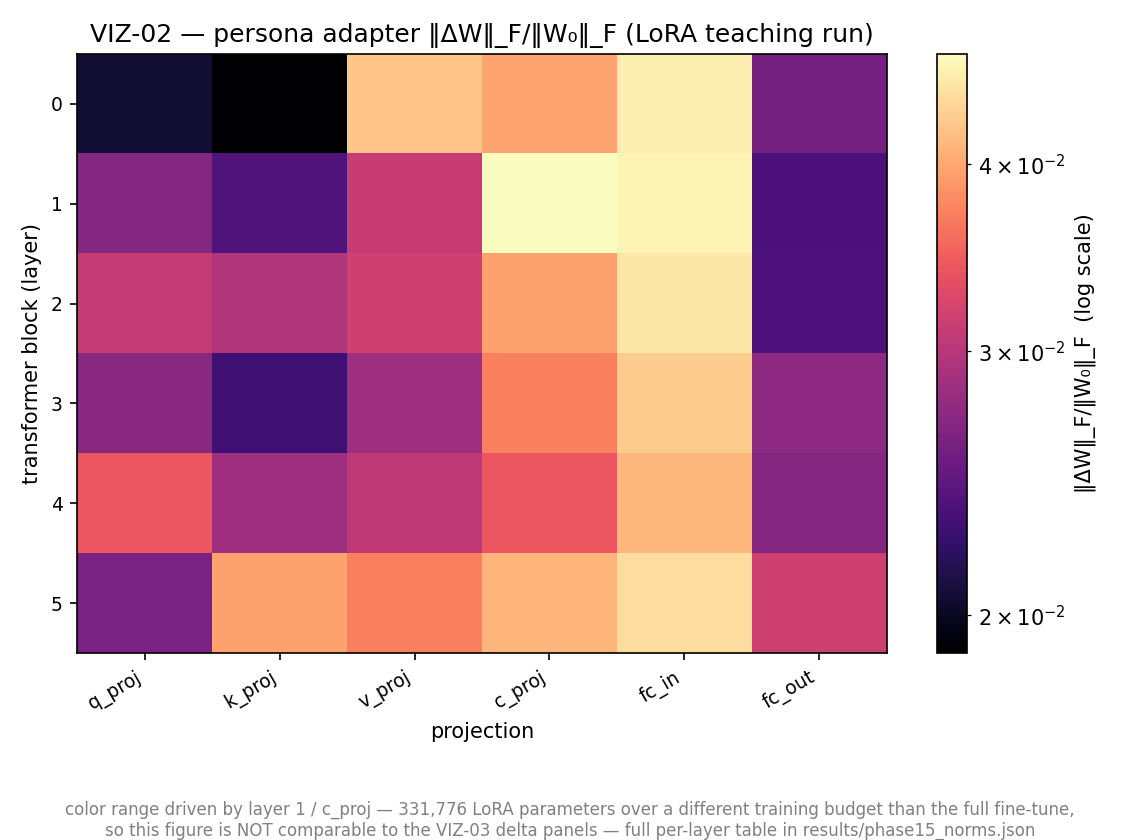

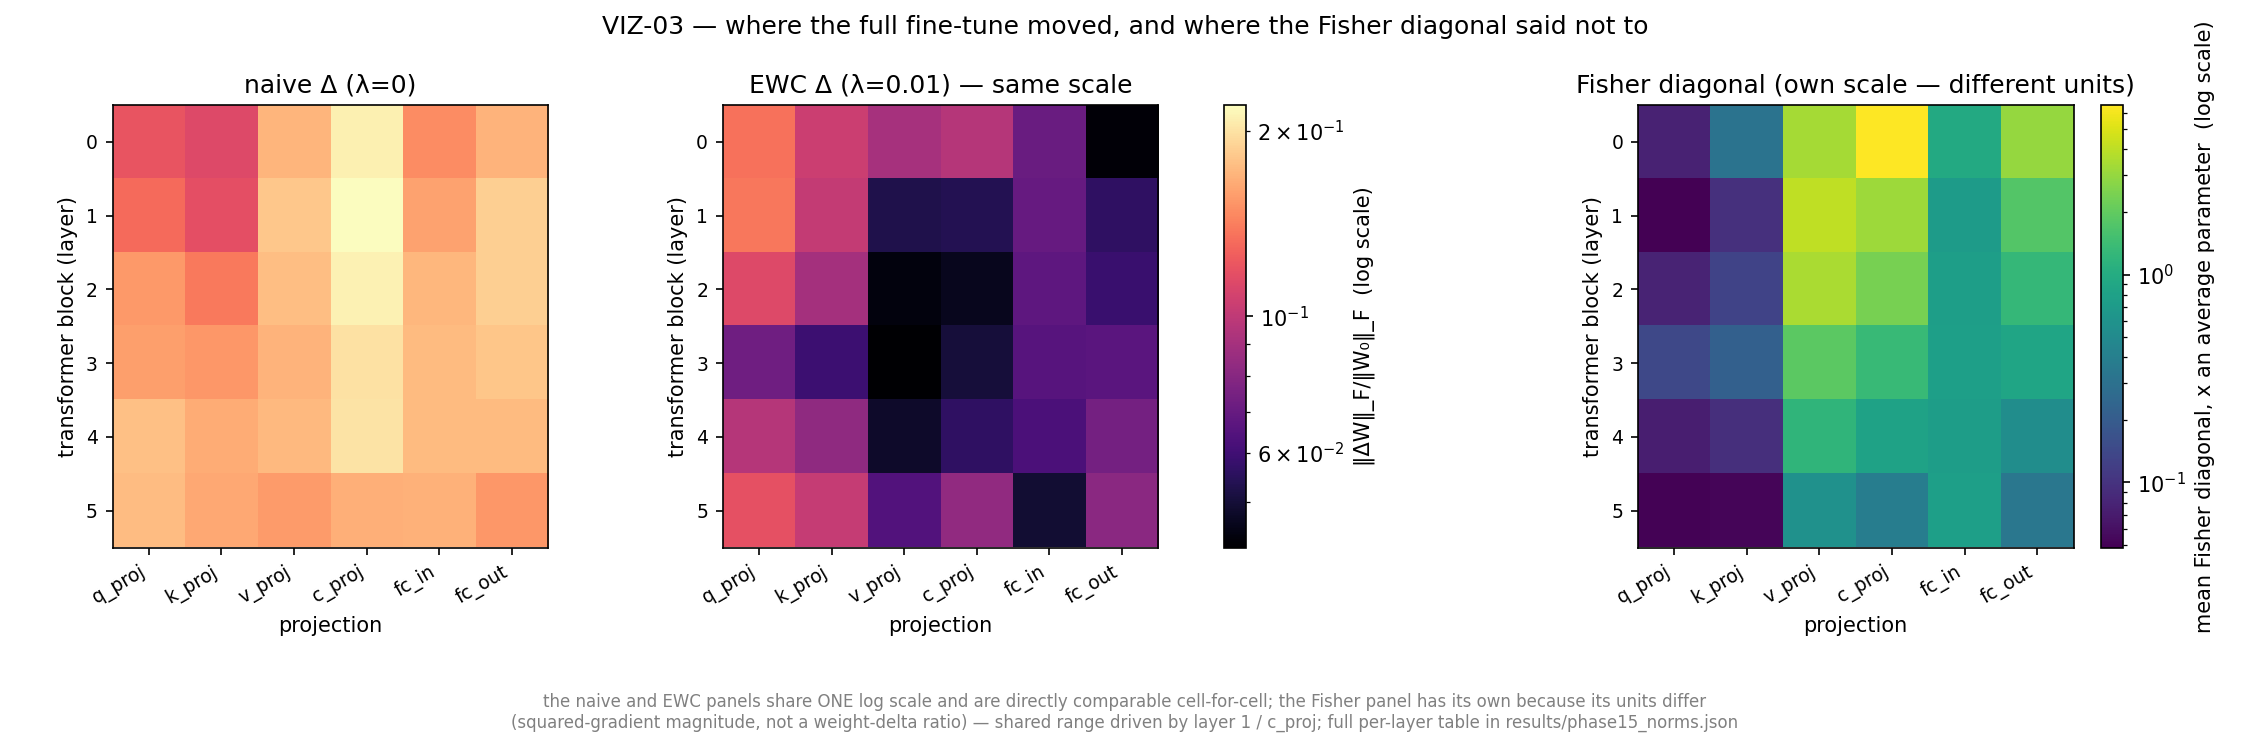

In [2]:
# The two v2.0 signature figures — committed PNGs, re-displayed rather than re-plotted.
display(Image(filename="results/phase15_adapter_delta.png"))  # VIZ-02 — adapter ΔW
display(Image(filename="results/phase15_fisher_ewc.png"))  # VIZ-03 — Fisher | naive | EWC

In [3]:
import json

# The single committed artifact both figures are drawn from (D-05/D-07). The provenance paths
# printed below are fields recorded INSIDE this JSON; this cell opens no checkpoint of its own.
with open("results/phase15_norms.json") as f:
    norms = json.load(f)

fisher = norms["blocks"]["fisher"]
print(f"artifact git_sha  : {norms['git_sha']}  (built {norms['built']})")
print(f"quantity          : {norms['quantity']}")
print(f"Fisher variant    : {fisher['variant']}")
print(f"  n_examples      : {fisher['n_examples']}")
print(f"  seed            : {fisher['seed']}")
print(f"  aggregate       : {norms['fisher_aggregate']}")
print()
print("comparison basis (machine-readable, D-06):")
for key, value in norms["comparison_basis"].items():
    if key != "note":
        print(f"  {key:<24}: {value}")
print()

projections = norms["projections"]
for name in ("adapter", "naive", "ewc", "fisher"):
    block = norms["blocks"][name]
    print(f"--- {name}  [{block['regime']}]  {block['param_count']:,} params")
    print(f"    source   : {block['source_ckpt']['path']}")
    print(f"    W0       : {block['w0_source']}")
    print("    layer" + "".join(f"{p:>13}" for p in projections))
    for layer in sorted(block["cells"], key=int):
        row = block["cells"][layer]
        print(f"    {layer:>5}" + "".join(f"{row[p]:>13.6f}" for p in projections))
    driver = block["vmax_driver"]
    print(
        f"    vmax driver: layer {driver['layer']} / {driver['projection']}"
        f" = {driver['value']:.6f}   non-positive cells: {block['nonpositive_cells']}"
    )
    print()

artifact git_sha  : d1e9eee21062976c398474324a513269ea78846e  (built 2026-08-02)
quantity          : relative_frobenius_change
Fisher variant    : empirical_diag_fisher/groundtruth_targets/mean_normalized
  n_examples      : 2000
  seed            : 1234
  aggregate       : mean

comparison basis (machine-readable, D-06):
  naive_vs_ewc            : True
  adapter_vs_full_finetune: False

--- adapter  [lora_adapter_teaching_run]  331,776 params
    source   : checkpoints/persona_adapter.pt
    W0       : checkpoints/convbase_best.pt
    layer       q_proj       k_proj       v_proj       c_proj        fc_in       fc_out
        0     0.020578     0.018873     0.042305     0.039809     0.045958     0.025826
        1     0.026898     0.023818     0.031103     0.047386     0.046507     0.023574
        2     0.030907     0.029644     0.031573     0.039546     0.045275     0.023744
        3     0.027115     0.022943     0.028417     0.036977     0.042860     0.027396
        4     0.03408

## Was the dodging real? The pre-registered correlation

The claim the three-panel figure invites — *EWC avoids the coordinates Fisher marks as
important* — was **measured**, under a decision rule committed to git **before** the artifact it
reads existed (`scripts/phase15_stats.py` @ `0e1af98`; the artifact @ `d1e9eee`).

Spearman **ρ = 0.801544** between Fisher magnitude and the per-cell Δ reduction
(`naiveΔ − ewcΔ`) across all **n = 36** cells; 95% bootstrap CI **[0.597984, 0.920291]**, which
excludes zero; permutation **p = 0.000010**, descriptive only. **GATE PASSES.**

**Read it for exactly what it is.** ρ is a **rank** correlation, not an effect size: it says EWC
pulls movement back hardest where Fisher is highest, and it does *not* say EWC dodges 80% of the
movement. The sign is the falsifiable claim the gate tested; the magnitude is descriptive and
bounded by n = 36, where a percentile bootstrap is known to be biased and anti-conservative. Nor
did EWC move less everywhere — **2 of the 36 cells moved further under EWC** (layer 0 / `q_proj`,
layer 1 / `q_proj`). Both signed values are inside this ρ; none were filtered out.

The full pre-registration table, the seed, the resample counts and both verdict branches live in
`results/phase13_ab_report.md` → `## Phase 15 Addendum`. They are not restated here.

## The caveats are part of the result

Two bounds on the headline numbers above, quoted from their own sources — reproduced verbatim,
because the caveat is part of the result, not a footnote to it.

Bounding *"EWC mitigates forgetting"* — from `results/phase13_ab_report.md`, `## Gate Verdict`:

> The scope of this verdict is exactly the quantity the gate measures: **teacher-forced retention
> perplexity on the frozen sub-bin**. It is not a claim about free-running story generation — see
> `## Retention Samples`, which reports a measured negative result on that axis.

Bounding *"the adapter recalls the persona closed-book"* — from
`results/phase14_recall_report.md`, `## Threats To Validity` →
`### 2. The soft tier is excluded from the gate (D-05)`:

> See `## Soft Tier — Excluded From The Gate (D-05)`. Two of the taught facts contribute nothing to
> either threshold, so the headline number describes the proper-noun core only — a narrower set
> than "everything the adapter was taught."

All **nine** honest negatives — each quoting its source exactly, visibly truncated rather than
paraphrased, ordered by which claim it bounds — are in
[`docs/REPORT.md` → Milestone 2 Limitations](docs/REPORT.md#milestone-2-limitations--nine-honest-negatives-quoted).